In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [145]:
# Listando as unidades de saude e alterando e ordenando pela sigla de cada unidade
def gerar_quadrimestre(caminho, q):

  quadrimestre = pd.read_csv(f'{str(caminho)}', sep=';', encoding='latin1')
  quadrimestre.loc[4,'Nome UBS'] = 'PROGRAMA SAUDE DA FAMILIA EQUIPE F POTIM'
  quadrimestre.drop('Sigla', axis=1, inplace=True)
  quadrimestre['Quadrimestre'] = str(f'{q}')
  return quadrimestre

In [146]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [147]:
primeiro_quadrimestre = gerar_quadrimestre('/content/drive/MyDrive/Aulas Python /Pandas/Indicadores de desempenho Potim/indicadores/2023/1Q_2023.csv', '1° Quadrimestre')
primeiro_quadrimestre

,CNES,Nome UBS,INE,Pré-Natal (6 consultas) (%),Pré-Natal (Sífilis e HIV) (%),Gestantes Saúde Bucal (%),Cobertura Citopatológico (%),Cobertura Polio e Penta (%),Hipertensão (PA Aferida) (%),Diabetes (Hemoglobina Glicada) (%),Quadrimestre
0,6871607,PROGRAMA SAUDE DA FAMILIA EQUIPE C POTIM,345377,0,29,29,6,76,17,31,1° Quadrimestre
1,7035934,PROGRAMA SAUDE DA FAMILIA EQUIPE D POTIM,345385,0,25,50,8,43,5,4,1° Quadrimestre
2,6871577,PROGRAMA SAUDE DA FAMILIA EQUIPE A POTIM,345350,0,29,0,9,75,34,17,1° Quadrimestre
3,6871593,PROGRAMA SAUDE DA FAMILIA EQUIPE B POTIM,345369,5,47,42,9,76,30,6,1° Quadrimestre
4,918113,PROGRAMA SAUDE DA FAMILIA EQUIPE F POTIM,2234629,0,50,38,7,100,55,30,1° Quadrimestre
5,7497024,PROGRAMA SAUDE DA FAMILIA EQUIPE E POTIM,1532847,0,40,20,1,89,44,26,1° Quadrimestre


In [148]:
def gerar_grafico_por_quadrimestre(df):
  indicadores = df.columns[3:-1]
  lista_esf = df['Nome UBS'].unique()
  lista_esf = sorted(lista_esf)

  for esf in lista_esf:
      dados = df.loc[df['Nome UBS'] == esf, indicadores]
      valores = dados.values.flatten()

      fig, ax = plt.subplots(figsize=(10, 6))
      bars = ax.barh(indicadores, valores)

      ax.set_title(f'Indicadores de Desempenho - 1° Quadrimestre\n{esf}', fontsize=16, loc='left')
      ax.set_xlim(0, 100)
      ax.set_xlabel('Percentual (%)')
      ax.tick_params(axis='x', rotation=45)
      ax.grid(axis='x', linestyle='--', alpha=0.5)
      ax.spines['top'].set_visible(False)
      ax.spines['right'].set_visible(False)

      for bar in bars:
          width = bar.get_width()
          ax.text(
              width + 1,
              bar.get_y() + bar.get_height() / 2,
              f'{width:.1f}%',
              va='center', ha='left')
      os.makedirs('graficos', exist_ok=True)  # cria a pasta se não existir
      plt.savefig(f'graficos/{esf}-por-quadimestre', dpi=300, bbox_inches='tight')
  plt.show()

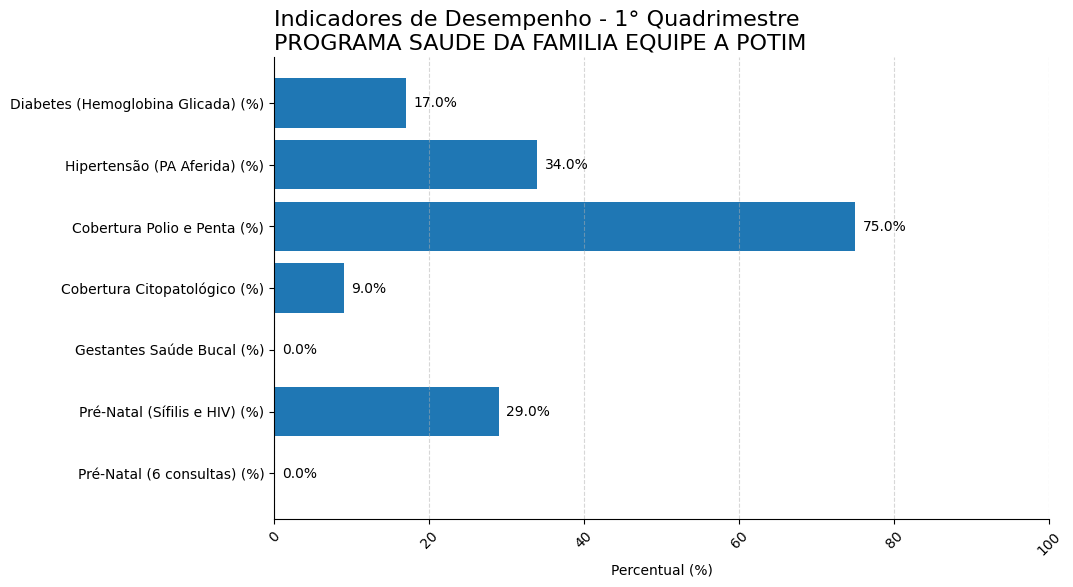

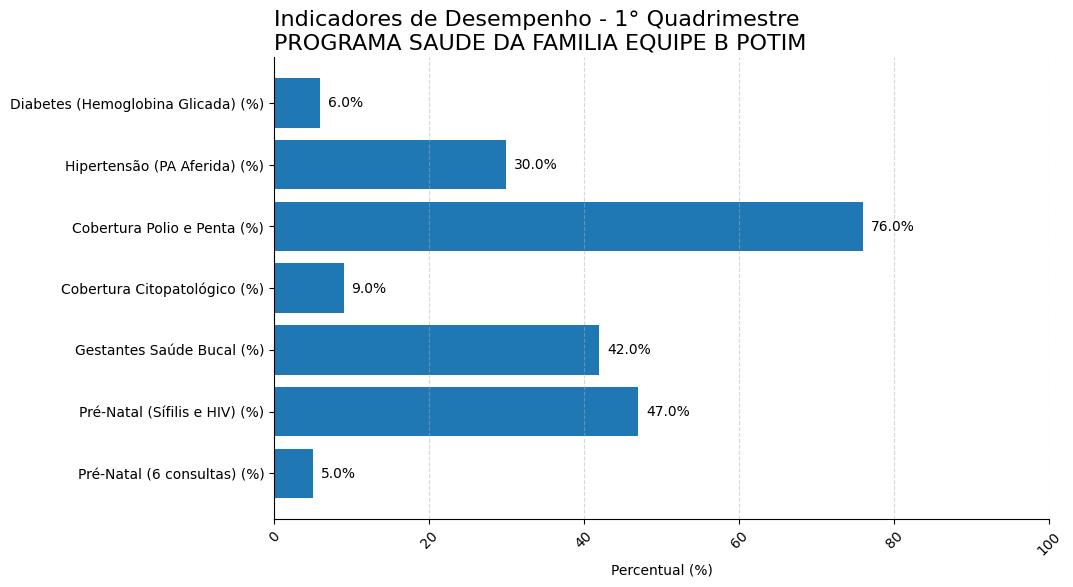

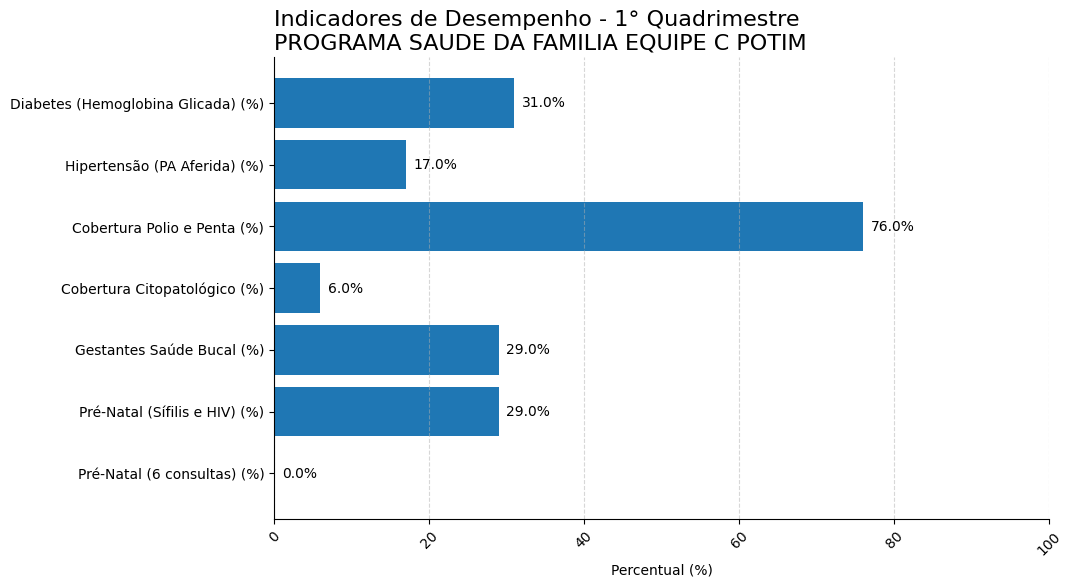

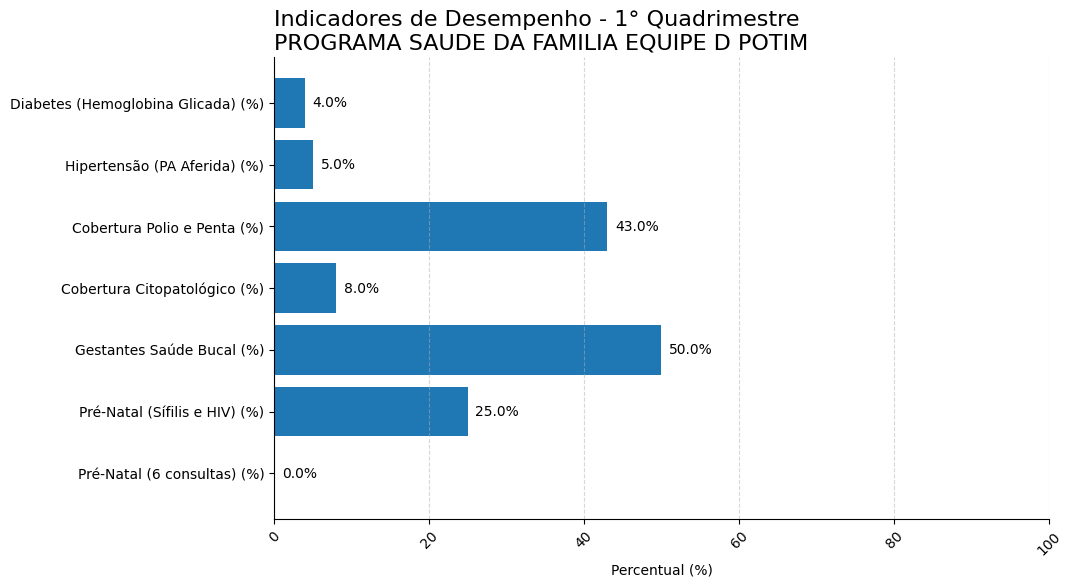

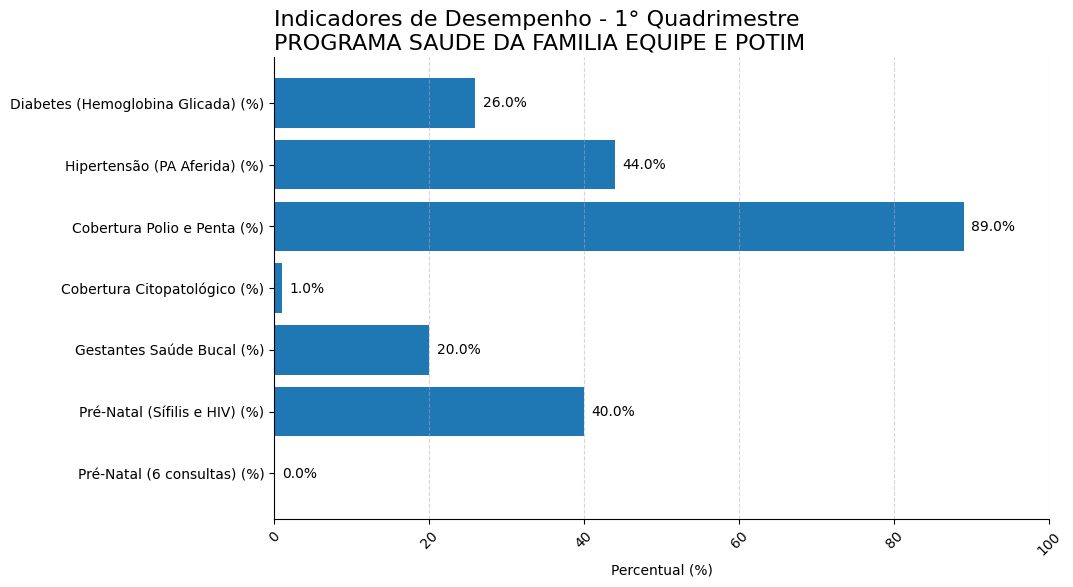

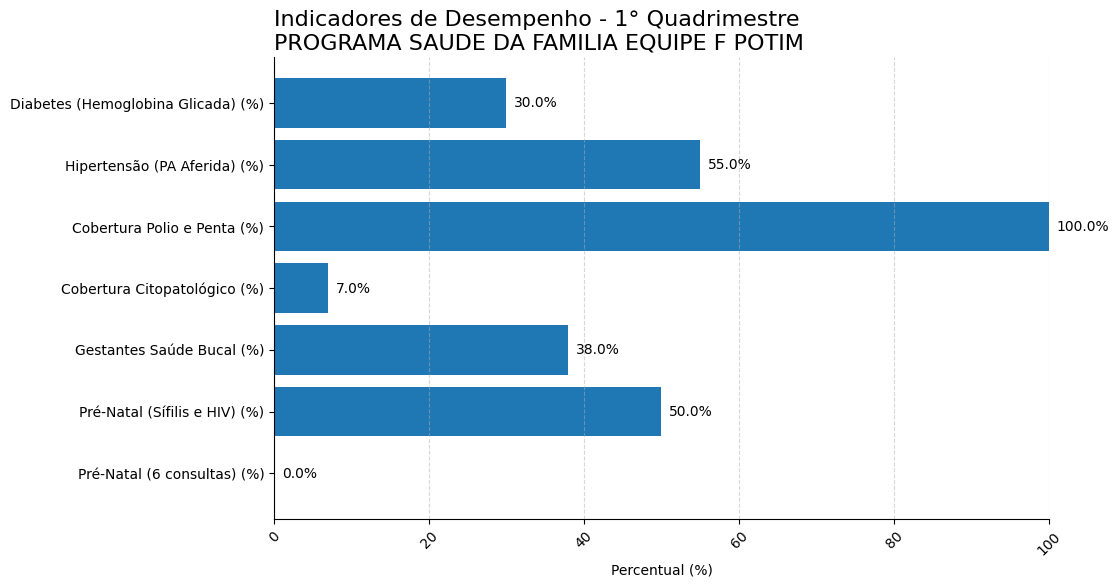

In [149]:
gerar_grafico_por_quadrimestre(primeiro_quadrimestre)

In [150]:
segundo_quadrimestre = gerar_quadrimestre('/content/drive/MyDrive/Aulas Python /Pandas/Indicadores de desempenho Potim/indicadores/2023/2Q_2023.csv', '2° Quadrimestre')
terceiro_quadrimestre = gerar_quadrimestre('/content/drive/MyDrive/Aulas Python /Pandas/Indicadores de desempenho Potim/indicadores/2023/3Q_2023.csv', '3° Quadrimestre')

In [151]:
indicadores_2023 = pd.concat([primeiro_quadrimestre, segundo_quadrimestre, terceiro_quadrimestre], axis=0, join='outer')

In [152]:
indicadores_2023

,CNES,Nome UBS,INE,Pré-Natal (6 consultas) (%),Pré-Natal (Sífilis e HIV) (%),Gestantes Saúde Bucal (%),Cobertura Citopatológico (%),Cobertura Polio e Penta (%),Hipertensão (PA Aferida) (%),Diabetes (Hemoglobina Glicada) (%),Quadrimestre
0,6871607,PROGRAMA SAUDE DA FAMILIA EQUIPE C POTIM,345377,0,29,29,6,76,17,31,1° Quadrimestre
1,7035934,PROGRAMA SAUDE DA FAMILIA EQUIPE D POTIM,345385,0,25,50,8,43,5,4,1° Quadrimestre
2,6871577,PROGRAMA SAUDE DA FAMILIA EQUIPE A POTIM,345350,0,29,0,9,75,34,17,1° Quadrimestre
3,6871593,PROGRAMA SAUDE DA FAMILIA EQUIPE B POTIM,345369,5,47,42,9,76,30,6,1° Quadrimestre
4,918113,PROGRAMA SAUDE DA FAMILIA EQUIPE F POTIM,2234629,0,50,38,7,100,55,30,1° Quadrimestre
5,7497024,PROGRAMA SAUDE DA FAMILIA EQUIPE E POTIM,1532847,0,40,20,1,89,44,26,1° Quadrimestre
0,6871607,PROGRAMA SAUDE DA FAMILIA EQUIPE C POTIM,345377,47,67,47,8,84,49,29,2° Quadrimestre
1,7035934,PROGRAMA SAUDE DA FAMILIA EQUIPE D POTIM,345385,40,70,60,13,91,30,20,2° Quadrimestre
2,6871577,PROGRAMA SAUDE DA FAMILIA EQUIPE A POTIM,345350,43,57,29,10,88,33,15,2° Quadrimestre
3,6871593,PROGRAMA SAUDE DA FAMILIA EQUIPE B POTIM,345369,20,67,13,11,67,43,13,2° Quadrimestre


In [153]:
def gerar_grafico_ano(df):
    indicadores = df.columns[3:-1]
    lista_esf = sorted(df['Nome UBS'].unique())
    quadrimestres = sorted(df['Quadrimestre'].unique())
    n_quadrimestres = len(quadrimestres)

    cores = ['#4B8BBE', '#306998', '#FFDD57', '#FFD43B', '#646464']

    for esf in lista_esf:
        dados = df[df['Nome UBS'] == esf]
        fig, ax = plt.subplots(figsize=(12, 7))
        x = np.arange(len(indicadores))
        largura = 0.15

        for i, quadrimestre in enumerate(quadrimestres):
            valores = dados[dados['Quadrimestre'] == quadrimestre][indicadores].values.flatten()
            posicoes = x + (i - n_quadrimestres / 2) * largura + largura / 2
            bars = ax.bar(posicoes, valores, width=largura, label=f'{quadrimestre}', color=cores[i % len(cores)])

            for bar in bars:
              height = bar.get_height()
              ax.text(
                  bar.get_x() + bar.get_width() / 2,
                  height + 1,
                  height,
                  ha='center',
                  va='bottom'
              )

        ax.set_title(f'Indicadores de desempenho 2023\n{esf}', fontsize=16, fontweight='bold', pad=20)
        ax.set_ylim(0,100)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xticks(x)
        ax.set_xticklabels(indicadores, rotation=45, ha='right')
        ax.set_ylabel('Percetunal (%)')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.legend()
        os.makedirs('graficos', exist_ok=True)  # cria a pasta se não existir
        plt.savefig(f'graficos/{esf}-anual.png', dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.close(fig)

In [154]:
gerar_grafico_ano(indicadores_2023)